Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


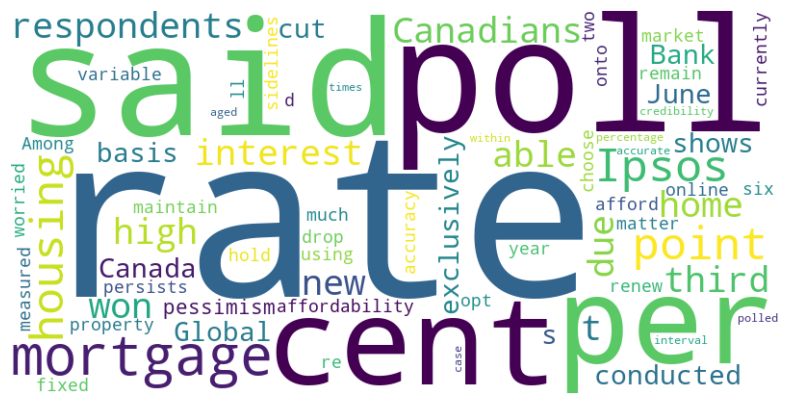

Original Article Text: Instructions: Want to discuss? Please read our Commenting Policy first. 
				If you get Global News from Instagram or Facebook - that will be changing. Find out how you can still connect with us.			 The first interest rate cut from the Bank of Canada in more than four years will not be enough to help most prospective homebuyers feeling sidelined by high borrowing costs, new polling suggests. The Ipsos poll conducted exclusively for Global News after the Bank of Canada’s 25-basis-point rate cut o ...

Combined Summary: Ipsos poll conducted exclusively for Global News after the Bank of Canada’s 25-basis-point rate cut on June 5 shows pessimism about housing affordability persists. six in 10 respondents said they’ll remain on the sidelines of the housing market due to high interest rates. some 45 per cent of respondents maintain that they won’t be able to afford a home no matter how much interest rates drop.

two-thirds (67 per cent) of Canadians with a mortgage sai

In [14]:
import requests
from bs4 import BeautifulSoup
from transformers import T5ForConditionalGeneration, T5Tokenizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load the pre-trained T5 model and tokenizer
model = T5ForConditionalGeneration.from_pretrained('t5-base')
tokenizer = T5Tokenizer.from_pretrained('t5-base', legacy=False)

def fetch_article_content(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    paragraphs = soup.find_all('p')
    article_text = ' '.join([para.get_text() for para in paragraphs])
    
    return article_text

def chunk_text(text, max_chunk_size=512):
    """Split text into chunks of a specified max size."""
    sentences = text.split('. ')
    current_chunk = []
    current_chunk_size = 0
    chunks = []
    
    for sentence in sentences:
        sentence_size = len(tokenizer.encode(sentence, add_special_tokens=False))
        if current_chunk_size + sentence_size > max_chunk_size:
            chunks.append(' '.join(current_chunk))
            current_chunk = [sentence]
            current_chunk_size = sentence_size
        else:
            current_chunk.append(sentence)
            current_chunk_size += sentence_size
    
    if current_chunk:
        chunks.append(' '.join(current_chunk))
    
    return chunks

def summarize(text, max_length=350, min_length=10):
    input_text = "summarize: " + text
    input_ids = tokenizer.encode(input_text, return_tensors="pt", add_special_tokens=True)
    
    summary_ids = model.generate(
        input_ids,
        max_length=max_length,
        min_length=min_length,
        num_beams=6,  # Using beam search to improve quality
        length_penalty=1.5,  # Adjust length penalty to encourage longer/smaller summaries
        early_stopping=True
    )
    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    return summary

def classify_sentiment(text):
    input_text = "sst2 sentence: " + text
    input_ids = tokenizer.encode(input_text, return_tensors="pt", add_special_tokens=True)
    
    output_ids = model.generate(input_ids, max_length=2, num_beams=2, length_penalty=2.5, early_stopping=True)
    sentiment = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    
    return sentiment

def generate_word_cloud(text):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    # Display the word cloud using matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

def process_news_url(url, summary_max_length=350, summary_min_length=10):
    article_text = fetch_article_content(url)
    chunks = chunk_text(article_text)
    summaries = [summarize(chunk, max_length=summary_max_length, min_length=summary_min_length) for chunk in chunks]
    
    combined_summary = '\n\n'.join(summaries)
    sentiment = classify_sentiment(combined_summary)
    
    # Generate the word cloud
    generate_word_cloud(combined_summary)
    
    return article_text, combined_summary, sentiment

# URL input
news_url = "https://globalnews.ca/news/10557513/interest-rate-cut-bank-of-canada-housing-ipsos/"
article_text, combined_summary, sentiment = process_news_url(news_url, summary_max_length=100, summary_min_length=50)

print("Original Article Text:", article_text[:500], "...")
print("\nCombined Summary:", combined_summary)
print("\nSentiment:", sentiment)